# Quantitative Segmentation Evaluation 

Notebook to evaluate the quality of our segmentation model by comparing the output of the model with our manual masks

In [1]:
import os
import copy 
import glob 

import random 

import numpy as np 
#from scipy.ndimage import ndimage
import torch 
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large
import torchvision.transforms as T

import cv2 
from PIL import Image
from pycocotools.coco import COCO

import matplotlib.pyplot as plt

from pycocotools import mask as maskUtils

import warnings 



## 1) Read in and initialise segmentation model

In [2]:
def get_model(model_path, device=None):
    checkpoints = torch.load(model_path, map_location=device, weights_only=True)
    model = deeplabv3_mobilenet_v3_large(num_classes=2, aux_loss=True).to(device)
    model.load_state_dict(checkpoints, strict=False)
    return model 

In [3]:

device = torch.device(
            "mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built() \
            else ("cuda" if torch.cuda.is_available() 
            else "cpu")
        )

In [4]:
model_path = os.path.join(os.path.abspath("../"), "model", "object_detection", "model_mbv3_iou_mix_2C049.pth")
model = get_model(model_path, device).to(device)
model.eval()

DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride

## Write a pipeline that produces the segmentation mask for a particular input image

In [5]:
def image_preprocess_transforms(mean=(0.4611, 0.4359, 0.3905), std=(0.2193, 0.2150, 0.2109)):
    common_transforms = T.Compose([T.ToTensor(), T.Normalize(mean, std),])
    return common_transforms

def calc_segmentation_mask(model, img, small_img_size, device, plot=True): 
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    resized_img = cv2.resize(img, (small_img_size, small_img_size), interpolation=cv2.INTER_NEAREST)
    preproc_transforms = image_preprocess_transforms()
    img_tens = preproc_transforms(resized_img)
    img_tens = torch.unsqueeze(img_tens, dim=0).to(device)

    with torch.inference_mode(): 
        out = model(img_tens)["out"]
    
    out = torch.argmax(
                out, 
                dim=1,
                keepdim=True).permute(0, 2, 3, 1)[0].cpu().numpy().squeeze().astype(np.uint8)
    mask = cv2.resize(out, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    
    if plot: 
        plt.figure(figsize=(12, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(img)
        plt.title('Original Image')
        plt.axis('off')

        plt.subplot(1, 3, 2)
        plt.imshow(mask, cmap='tab20')  
        plt.title('Segmentation Map')
        plt.axis('off')

        plt.subplot(1, 3, 3)
        plt.imshow(img)
        plt.imshow(mask, alpha=0.5, cmap='tab20')
        plt.title('Overlay')
        plt.axis('off')

        plt.tight_layout()
    
    return mask

## Import Manual Segmentation Information

In [6]:
# segmentation file information 
coco = COCO(os.path.abspath("../data/for_segmentation/result.json"))

# get all image ids
img_ids = coco.getImgIds()

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1900, 3460), dtype=uint8)

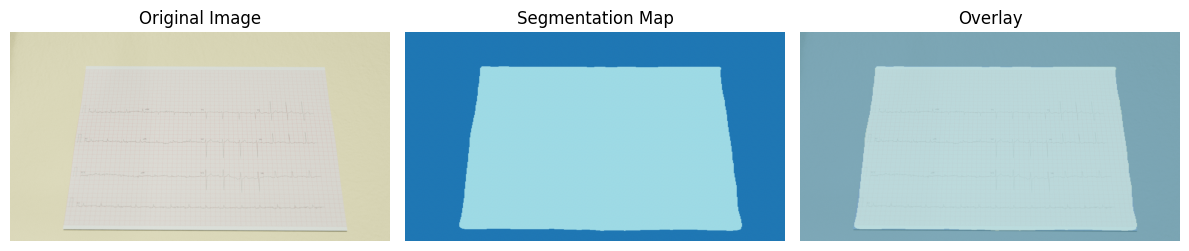

In [7]:
img_info = coco.loadImgs(random.choice([i for i in range(240)]))[0]
img = cv2.imread(img_info["file_name"])
calc_segmentation_mask(model, img=img, small_img_size=512, device=device, plot=True)

## Calculate IoU between masks

In [8]:
def calculate_iou(mask1, mask2): 
    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()
    
    if union == 0: 
        return 0.0 

    return intersection/union

In [9]:
def get_coco_mask(coco, img_id, img_shape):
    """Extract segmentation mask from COCO annotations"""
    # Get annotations for this image
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)
    
    # Create empty mask
    combined_mask = np.zeros((img_shape[0], img_shape[1]), dtype=np.uint8)
    
    # Combine all annotations into single mask
    for ann in anns:
        # COCO stores masks in RLE or polygon format
        if 'segmentation' in ann:
            if type(ann['segmentation']) == list:
                # Polygon format
                rle = maskUtils.frPyObjects(ann['segmentation'], img_shape[0], img_shape[1])
                m = maskUtils.decode(rle)
                if len(m.shape) == 3:
                    m = m.sum(axis=2) > 0  # Combine multiple polygons
            else:
                # RLE format
                if type(ann['segmentation']['counts']) == list:
                    rle = maskUtils.frPyObjects([ann['segmentation']], img_shape[0], img_shape[1])
                    m = maskUtils.decode(rle)[:,:,0]
                else:
                    m = maskUtils.decode(ann['segmentation'])
            
            combined_mask = np.logical_or(combined_mask, m).astype(np.uint8)
    
    return combined_mask

In [10]:
def calculate_boundary_metrics(pred_mask, gt_mask, distance_threshold=5):
    """
    Calculate boundary-based metrics
    """
    warnings.warn("Currently too slow to use lol")
    # Find boundaries
    pred_boundary = pred_mask ^ ndimage.binary_erosion(pred_mask)
    gt_boundary = gt_mask ^ ndimage.binary_erosion(gt_mask)
    
    # Distance transform
    gt_dist = ndimage.distance_transform_edt(~gt_boundary)
    pred_dist = ndimage.distance_transform_edt(~pred_boundary)
    
    # Boundary IoU
    boundary_iou = calculate_iou(pred_boundary, gt_boundary)
    
    # Boundary F1 (with tolerance)
    pred_near_gt = gt_dist[pred_boundary] < distance_threshold
    boundary_precision = np.mean(pred_near_gt) if pred_boundary.any() else 0
    
    gt_near_pred = pred_dist[gt_boundary] < distance_threshold
    boundary_recall = np.mean(gt_near_pred) if gt_boundary.any() else 0
    
    boundary_f1 = 2 * (boundary_precision * boundary_recall) / (boundary_precision + boundary_recall) \
                  if (boundary_precision + boundary_recall) > 0 else 0
    
    # Average boundary distance
    if pred_boundary.any() and gt_boundary.any():
        avg_distance = np.mean(gt_dist[pred_boundary])
    else:
        avg_distance = 0
    
    return {
        'boundary_iou': boundary_iou,
        'boundary_f1': boundary_f1,
        'boundary_precision': boundary_precision,
        'boundary_recall': boundary_recall,
        'avg_boundary_distance': avg_distance
    }

In [11]:
def find_document_corners(mask):
    """Find four corners of document from mask"""
    contours, _ = cv2.findContours(mask.astype(np.uint8), 
                                   cv2.RETR_EXTERNAL, 
                                   cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    
    largest = max(contours, key=cv2.contourArea)
    
    # Approximate to polygon
    epsilon = 0.02 * cv2.arcLength(largest, True)
    approx = cv2.approxPolyDP(largest, epsilon, True)
    
    if len(approx) >= 4:
        # Find 4 corners (top-left, top-right, bottom-right, bottom-left)
        corners = approx.reshape(-1, 2)
        
        # Sort corners
        center = corners.mean(axis=0)
        angles = np.arctan2(corners[:, 1] - center[1], 
                           corners[:, 0] - center[0])
        sorted_indices = np.argsort(angles)
        corners = corners[sorted_indices][:4]
        
        return corners
    return None

def calculate_corner_accuracy(pred_mask, gt_mask, threshold=10):
    """Calculate how accurately corners are detected"""
    pred_corners = find_document_corners(pred_mask)
    gt_corners = find_document_corners(gt_mask)
    
    if pred_corners is None or gt_corners is None:
        return {'corner_detected': False, 'avg_corner_error': None}
    
    # Find nearest matching corners
    distances = []
    for gt_corner in gt_corners:
        min_dist = np.min([np.linalg.norm(gt_corner - pred_corner) 
                          for pred_corner in pred_corners])
        distances.append(min_dist)
    
    avg_error = np.mean(distances)
    corners_accurate = all(d < threshold for d in distances)
    
    return {
        'corner_detected': True,
        'avg_corner_error': avg_error,
        'corners_accurate': corners_accurate,
        'max_corner_error': np.max(distances)
    }

In [12]:
def analyze_by_category(coco, model, device):#, categories_dict):
    """
    Analyze performance by image category
    categories_dict: {img_id: 'category_name', ...}
    """
    # results = {cat: {'ious': [], 'boundary_f1s': [], 'corner_errors': []} 
    #            for cat in set(categories_dict.values())}
    
    results = {"ious": [],
                "boundary_f1s": [], 
                "corner_errors": []}
    
    for img_id in coco.getImgIds():
        print(f"{img_id}")
        # if img_id not in categories_dict:
        #     continue
            
        # category = categories_dict[img_id]
        
        # Load and process image
        img_info = coco.loadImgs(img_id)[0]
        img = cv2.imread(img_info["file_name"])
        
        # Get masks
        pred_mask = calc_segmentation_mask(
                            model, img=img, small_img_size=512, 
                            device=device, plot=False)
        gt_mask = get_coco_mask(coco, img_id, img.shape)
        
        # Calculate metrics
        iou = calculate_iou(pred_mask, gt_mask)
        #boundary_metrics = calculate_boundary_metrics(pred_mask, gt_mask)
        corner_metrics = calculate_corner_accuracy(pred_mask, gt_mask)
        
        # Store results
        # results[category]['ious'].append(iou)
        # results[category]['boundary_f1s'].append(boundary_metrics['boundary_f1'])
        # if corner_metrics['corner_detected']:
        #     results[category]['corner_errors'].append(corner_metrics['avg_corner_error'])
        results['ious'].append(iou)
        #results['boundary_f1s'].append(boundary_metrics['boundary_f1'])
        if corner_metrics['corner_detected']:
            results['corner_errors'].append(corner_metrics['avg_corner_error'])
            
    return results

In [13]:
results = analyze_by_category(coco, model, device)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240


Number of images where corners detected = 241
Corner Error = 28.446426320149968 ± 64.89163813675835
Min CE = 7.451916346530042
Max CE = 622.1151814494159


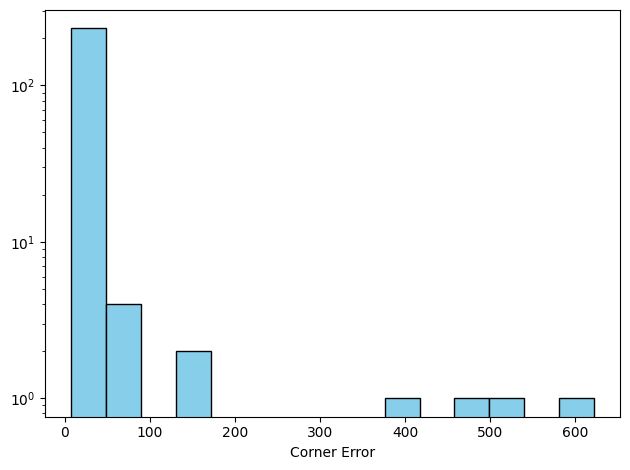

In [14]:
ce = np.array(results["corner_errors"])
print(f"Number of images where corners detected = {len(results["corner_errors"])}")
print(f"Corner Error = {np.mean(ce)} ± {np.std(ce)}")
print(f"Min CE = {np.min(ce)}")
print(f"Max CE = {np.max(ce)}")

fig, ax = plt.subplots()
ax.hist(ce, bins=15, color='skyblue', ec='black')
ax.set_yscale("log")
ax.set_xlabel("Corner Error")
fig.tight_layout()

IoU = 0.9787041879358739 ± 0.018683009622731863
Min IoU = 0.857135469412438
Max IoU = 0.993772961975903


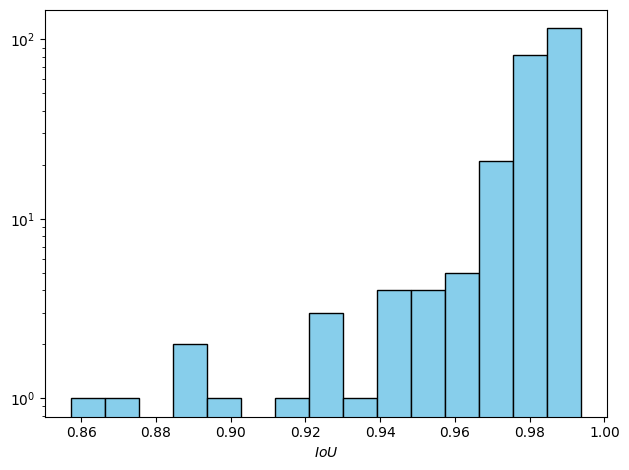

In [17]:
ious = np.array(results["ious"])
print(f"IoU = {np.mean(ious)} ± {np.std(ious)}")
print(f"Min IoU = {np.min(ious)}")
print(f"Max IoU = {np.max(ious)}")

fig, ax = plt.subplots()
ax.hist(ious, bins=15, edgecolor='black', color='skyblue')
ax.set_xlabel(r"$IoU$")
ax.set_yscale("log")
fig.tight_layout()

### Results:
* High corner error standard deviation relative to mean corner errors implies outliers
    * This isn't that surprising, it's probably due to the images with bent corners or where the corners are not in the image, so we can't detect 4 corners. You can see from the histogram there are very few images with this high corner error.  
* The code to calculate the boundary errors is currently very very slow and crashes the kernel, so not really running it
* Also not subdividing by "image quality" category: might want to do that later
* IoUs are exceptional

## More analysis

* convex hull IoU
* boundary box IoU